In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision  # <-- Đã thêm ở đây để fix lỗi của bạn
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Hệ thống sẵn sàng trên: {DEVICE}")

🚀 Hệ thống sẵn sàng trên: cuda


In [2]:
# =========================================================
# CELL 2: CẤU HÌNH ĐƯỜNG DẪN VÀ SIÊU THAM SỐ (CẬP NHẬT)
# =========================================================

# 1. Đường dẫn thư mục gốc chứa data 300 ảnh
DATA_ROOT_DIR = "/kaggle/input/datasets/duckkoder/datasetcustom-c-my-tk-trong-lp"

# 2. Đường dẫn model đã train trước đó (file .pth)
PRETRAINED_MODEL_PATH = "/kaggle/input/models/duckkoder/anti-ver1/pytorch/default/1/best_model_checkpoint.pth"

# 3. Cấu hình Training
IMG_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 7e-6
NUM_EPOCHS = 30
DROPOUT_RATE = 0.5

# 4. Cấu hình Loss (Security-First: Thà đánh nhầm còn hơn bỏ sót)
FOCAL_ALPHA = 0.65 
FOCAL_GAMMA = 2.0

# 5. Thiết bị chạy
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Đã thiết lập cấu hình. Sẵn sàng train trên: {DEVICE}")

✅ Đã thiết lập cấu hình. Sẵn sàng train trên: cuda


In [3]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None: identity = self.downsample(x)
        out += identity
        return self.relu(out)

class ResNet18_MSFF_AntiSpoof(nn.Module):
    def __init__(self, block=BasicBlock, layers=[2,2,2,2], num_classes=2): 
        super(ResNet18_MSFF_AntiSpoof, self).__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(DROPOUT_RATE), 
            nn.Linear(256 + 512, num_classes) 
        )

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_planes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_planes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = [block(self.in_planes, planes, stride, downsample)]
        self.in_planes = planes * block.expansion
        for _ in range(1, blocks): layers.append(block(self.in_planes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x)
        f3 = self.layer3(x); f4 = self.layer4(f3)
        out3 = torch.flatten(self.avgpool(f3), 1); out4 = torch.flatten(self.avgpool(f4), 1)
        return self.fc(torch.cat((out3, out4), dim=1))

In [4]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

# 1. Định nghĩa Class "Người gác cổng" (BẮT BUỘC phải có cái này mới chạy được Subset transform)
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 2. Định nghĩa Normalize và Transform
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20), 
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=15),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

# 3. Load và Chia 80/20
# Đảm bảo DATA_ROOT_DIR đã được khai báo ở Cell 2
full_new_dataset = datasets.ImageFolder(DATA_ROOT_DIR)

train_indices, test_indices = train_test_split(
    range(len(full_new_dataset)),
    test_size=0.2, 
    stratify=full_new_dataset.targets,
    random_state=42
)

# 4. Áp dụng Transform riêng biệt
train_data = ApplyTransform(Subset(full_new_dataset, train_indices), transform=train_transform)
test_data = ApplyTransform(Subset(full_new_dataset, test_indices), transform=test_transform)

# 5. Khởi tạo Loaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Đã fix lỗi! Train: {len(train_data)} | Test: {len(test_data)}")

✅ Đã fix lỗi! Train: 320 | Test: 81


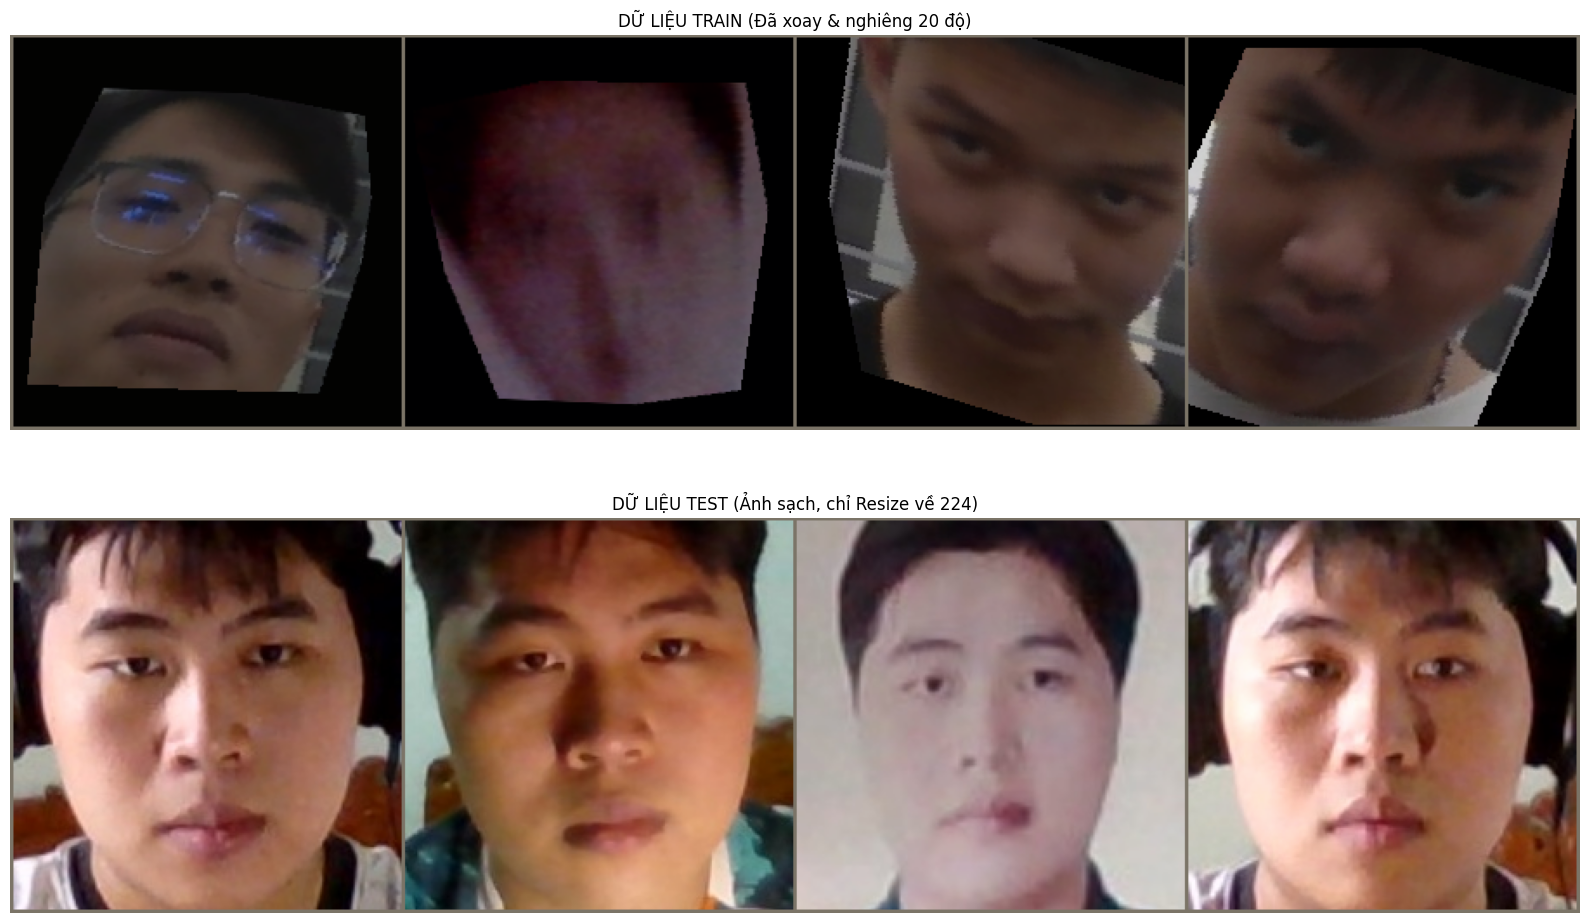

In [5]:
import torchvision

def imshow_compare(inp, title=None):
    """Hàm hiển thị ảnh đã chuẩn hóa về dạng nhìn thấy được"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title: plt.title(title)
    plt.axis('off')

# 1. Lấy 1 batch từ Train (Có Augmentation: xoay, nghiêng...)
inputs_train, classes_train = next(iter(train_loader))
grid_train = torchvision.utils.make_grid(inputs_train[:4]) # Lấy 4 ảnh đầu

# 2. Lấy 1 batch từ Test (Chỉ Resize 224: ảnh sạch, thẳng)
inputs_test, classes_test = next(iter(test_loader))
grid_test = torchvision.utils.make_grid(inputs_test[:4]) # Lấy 4 ảnh đầu

# 3. Vẽ lên màn hình để so sánh
plt.figure(figsize=(16, 10))

# Vẽ dòng Train
plt.subplot(2, 1, 1)
imshow_compare(grid_train, title="DỮ LIỆU TRAIN (Đã xoay & nghiêng 20 độ)")

# Vẽ dòng Test
plt.subplot(2, 1, 2)
imshow_compare(grid_test, title="DỮ LIỆU TEST (Ảnh sạch, chỉ Resize về 224)")

plt.tight_layout()
plt.show()

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.65, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = torch.tensor([alpha, 1 - alpha]).to(DEVICE)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = self.alpha.gather(0, targets.data.view(-1))
        return (alpha_t * ((1 - pt) ** self.gamma) * ce_loss).mean()

model = ResNet18_MSFF_AntiSpoof().to(DEVICE)
if os.path.exists(PRETRAINED_MODEL_PATH):
    model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=DEVICE))
    print("✅ Đã kế thừa trọng số model cũ.")

criterion = FocalLoss(alpha=FOCAL_ALPHA)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [7]:
history = {'loss': [], 'acc': []}
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    
    epoch_loss = running_loss / len(train_data)
    epoch_acc = running_corrects.double() / len(train_data)
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc.cpu().item())
    print(f'Epoch {epoch+1}: Loss {epoch_loss:.4f} | Acc {epoch_acc:.4f}')

torch.save(model.state_dict(), "final_classroom_model1.pth")

Epoch 1/30:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Loss 0.1582 | Acc 0.6813


Epoch 2/30:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 2: Loss 0.0626 | Acc 0.8438


Epoch 3/30:   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch 28: Loss 0.0202 | Acc 0.9656


Epoch 29/30:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 29: Loss 0.0269 | Acc 0.9313


Epoch 30/30:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 30: Loss 0.0312 | Acc 0.9250


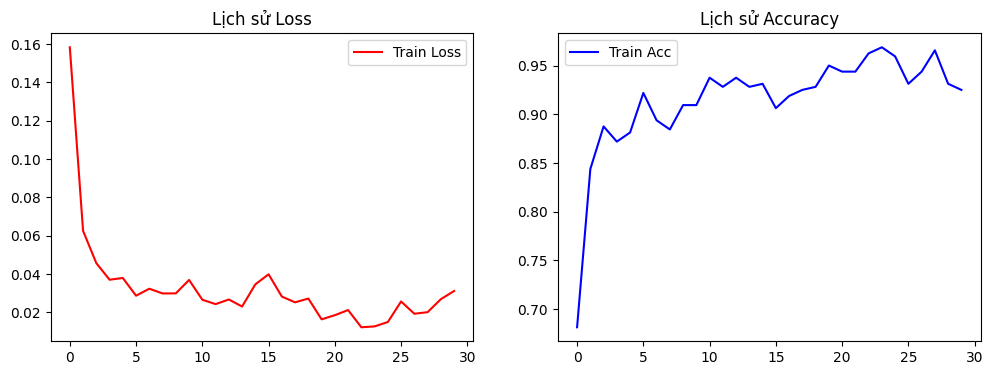

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], color='red', label='Train Loss')
plt.title('Lịch sử Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], color='blue', label='Train Acc')
plt.title('Lịch sử Accuracy')
plt.legend()
plt.show()

Testing:   0%|          | 0/6 [00:00<?, ?it/s]


--- BÁO CÁO PHÂN LOẠI (TEST SET) ---
              precision    recall  f1-score   support

        fake       1.00      1.00      1.00        31
        real       1.00      1.00      1.00        50

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81



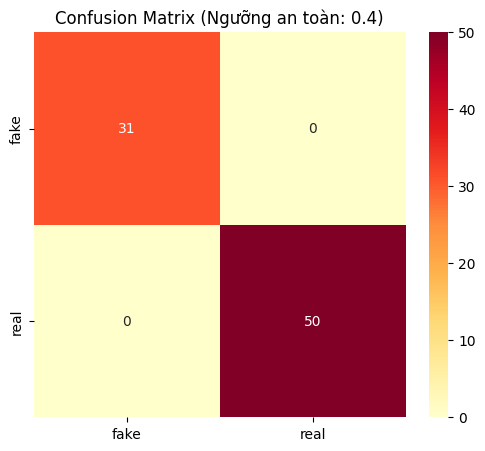

In [9]:
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(inputs.to(DEVICE))
        probs = torch.softmax(outputs, dim=1)[:, 1] # P(Fake)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Ngưỡng 0.4
threshold = 0.4 
final_preds = [1 if p > threshold else 0 for p in all_probs]

print("\n--- BÁO CÁO PHÂN LOẠI (TEST SET) ---")
# --- SỬA Ở ĐÂY: Thay test_dataset bằng full_new_dataset ---
print(classification_report(all_labels, final_preds, target_names=full_new_dataset.classes))

cm = confusion_matrix(all_labels, final_preds)
plt.figure(figsize=(6,5))
# --- SỬA Ở ĐÂY: Thay test_dataset bằng full_new_dataset ---
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=full_new_dataset.classes, yticklabels=full_new_dataset.classes)
plt.title(f'Confusion Matrix (Ngưỡng an toàn: {threshold})')
plt.show()